# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

# Reporte actualizado: predicción de tráfico de recetas

Este notebook usa como base la plantilla adjunta y carga `recipe_site_traffic_2212.csv` como `df`.

Se aplica el tratamiento de valores faltantes documentado en el plan:

- Variables nutricionales: convertir `NA` a `NaN` e imputar por mediana agrupada por categoría.
- Variable objetivo `high_traffic`: clasificación binaria estricta, donde `High = 1` y `NA`/nulos = `0`.

Por tanto, el proyecto se desarrolla como **clasificación binaria supervisada** según el plan original.


In [1]:
# Imports y configuración general
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
RANDOM_STATE = 42


## 1. Carga de datos

La base se integra explícitamente como `df`. Se conserva `df` como dataset crudo y se crean copias para limpieza, EDA y modelado.


In [2]:
# Cargar la base como df
DATA_PATH = Path("recipe_site_traffic_2212.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/recipe_site_traffic_2212.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró recipe_site_traffic_2212.csv. Coloca el CSV en el mismo directorio del notebook."
    )

df = pd.read_csv(DATA_PATH)
print(f"Archivo cargado: {DATA_PATH}")
print(f"Dimensiones de df: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
df.head()


Archivo cargado: recipe_site_traffic_2212.csv
Dimensiones de df: 947 filas x 8 columnas


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [3]:
# Vista inicial de tipos, nulos y valores únicos
initial_audit = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
    "unique_values_including_na": df.nunique(dropna=False).values,
})
initial_audit


,column,dtype,missing_count,missing_pct,unique_values_including_na
0,recipe,int64,0,0.00,947
1,calories,float64,52,5.49,892
2,carbohydrate,float64,52,5.49,836
3,sugar,float64,52,5.49,667
4,protein,float64,52,5.49,773
5,category,object,0,0.00,11
6,servings,object,0,0.00,6
7,high_traffic,object,373,39.39,2


## 2. Validación y limpieza de datos por columna

La validación sigue el plan documentado. Los nulos de nutrientes se imputan por mediana de categoría, y los nulos de `high_traffic` se codifican como clase 0.

Decisiones por columna:

- `recipe`: identificador único; se excluye de features para evitar sobreajuste.
- `calories`, `carbohydrate`, `sugar`, `protein`: conversión a numérico e imputación por mediana de `category_clean`.
- `category`: normalización de texto y fusión obligatoria `Chicken Breast` → `Chicken`.
- `servings`: extracción de número de porciones y creación de bandera `is_snack_serving`.
- `high_traffic`: `High = 1`; `NA`/nulos = `0`.


In [4]:
expected_columns = [
    "recipe", "calories", "carbohydrate", "sugar", "protein", "category", "servings", "high_traffic"
]
missing_expected = sorted(set(expected_columns) - set(df.columns))
unexpected_columns = sorted(set(df.columns) - set(expected_columns))

if missing_expected:
    raise ValueError(f"Faltan columnas esperadas: {missing_expected}")

print(f"Columnas inesperadas: {unexpected_columns if unexpected_columns else 'ninguna'}")

df_clean = df.copy()

# Convertir marcadores textuales de NA a NaN lógicos.
df_clean = df_clean.replace({"NA": np.nan, "": np.nan})

# recipe como identificador numérico.
df_clean["recipe"] = pd.to_numeric(df_clean["recipe"], errors="coerce")

# Conversión numérica de nutrientes.
nutrient_cols = ["calories", "carbohydrate", "sugar", "protein"]
for col in nutrient_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Categoría limpia y fusión requerida por el plan.
df_clean["category_raw"] = df_clean["category"].astype(str).str.strip()
df_clean["category_clean"] = df_clean["category_raw"].replace({"Chicken Breast": "Chicken"})

# Servings limpio.
servings_text = df_clean["servings"].astype(str).str.strip()
df_clean["servings_clean"] = pd.to_numeric(servings_text.str.extract(r"(\d+)")[0], errors="coerce")
df_clean["is_snack_serving"] = servings_text.str.contains("snack", case=False, na=False).astype(int)

# Variable objetivo según plan: High = 1; NA/nulos = 0.
df_clean["high_traffic_binary"] = np.where(df_clean["high_traffic"].eq("High"), 1, 0)
df_clean["target_label"] = df_clean["high_traffic_binary"].map({1: "high", 0: "not_high"})

# Imputación por mediana agrupada por categoría para EDA.
df_eda = df_clean.copy()
for col in nutrient_cols:
    group_median = df_eda.groupby("category_clean")[col].transform("median")
    df_eda[f"{col}_imputed"] = df_eda[col].fillna(group_median).fillna(df_eda[col].median())

print("Distribución de la variable objetivo después del tratamiento planificado:")
display(df_clean["target_label"].value_counts().to_frame("count"))

print("Categorías después de limpieza:")
display(df_clean["category_clean"].value_counts().to_frame("count"))


Columnas inesperadas: ninguna
Distribución de la variable objetivo después del tratamiento planificado:


,count
target_label,
high,574
not_high,373


Categorías después de limpieza:


,count
category_clean,
Chicken,172
Breakfast,106
Beverages,92
Lunch/Snacks,89
Potato,88
Pork,84
Dessert,83
Vegetable,83
Meat,79


In [5]:
# Reporte de validación por columna
validation_rows = []

validation_rows.append({
    "column": "recipe",
    "observed_issue": f"{df_clean['recipe'].isna().sum()} nulos; {df_clean['recipe'].duplicated().sum()} duplicados",
    "cleaning_or_decision": "Validado como identificador único. Se excluye del modelado.",
    "post_clean_result": f"rango {int(df_clean['recipe'].min())} a {int(df_clean['recipe'].max())}"
})

for col in nutrient_cols:
    validation_rows.append({
        "column": col,
        "observed_issue": (
            f"{df_clean[col].isna().sum()} nulos; "
            f"{int((df_clean[col] < 0).sum())} valores negativos"
        ),
        "cleaning_or_decision": "Convertido a numérico. Imputación por mediana de category_clean para EDA y dentro del pipeline para modelado.",
        "post_clean_result": (
            f"mediana raw={df_clean[col].median():.2f}; "
            f"mediana imputada EDA={df_eda[f'{col}_imputed'].median():.2f}"
        )
    })

validation_rows.append({
    "column": "category",
    "observed_issue": f"{df_clean['category'].isna().sum()} nulos; {df_clean['category_raw'].nunique()} categorías crudas",
    "cleaning_or_decision": "Se normalizan espacios y se fusiona Chicken Breast con Chicken.",
    "post_clean_result": f"{df_clean['category_clean'].nunique()} categorías limpias"
})

validation_rows.append({
    "column": "servings",
    "observed_issue": f"valores crudos: {sorted(df_clean['servings'].astype(str).unique())}",
    "cleaning_or_decision": "Se extrae número de porciones y se crea bandera is_snack_serving.",
    "post_clean_result": (
        f"{df_clean['servings_clean'].isna().sum()} nulos tras limpieza; "
        f"{int(df_clean['is_snack_serving'].sum())} registros marcados como snack"
    )
})

validation_rows.append({
    "column": "high_traffic",
    "observed_issue": f"{df_clean['high_traffic'].isna().sum()} nulos originales; valores no nulos: {df_clean['high_traffic'].dropna().unique().tolist()}",
    "cleaning_or_decision": "Tratamiento documentado en plan: High = 1; NA/nulos = 0.",
    "post_clean_result": (
        f"high={int(df_clean['high_traffic_binary'].sum())}; "
        f"not_high={int((df_clean['high_traffic_binary'] == 0).sum())}"
    )
})

validation_report = pd.DataFrame(validation_rows)
validation_report


,column,observed_issue,cleaning_or_decision,post_clean_result
0,recipe,0 nulos; 0 duplicados,Validado como identificador único. Se excluye ...,rango 1 a 947
1,calories,52 nulos; 0 valores negativos,Convertido a numérico. Imputación por mediana ...,mediana raw=288.55; mediana imputada EDA=296.92
2,carbohydrate,52 nulos; 0 valores negativos,Convertido a numérico. Imputación por mediana ...,mediana raw=21.48; mediana imputada EDA=21.19
3,sugar,52 nulos; 0 valores negativos,Convertido a numérico. Imputación por mediana ...,mediana raw=4.55; mediana imputada EDA=4.40
4,protein,52 nulos; 0 valores negativos,Convertido a numérico. Imputación por mediana ...,mediana raw=10.80; mediana imputada EDA=11.24
5,category,0 nulos; 11 categorías crudas,Se normalizan espacios y se fusiona Chicken Br...,10 categorías limpias
6,servings,"valores crudos: ['1', '2', '4', '4 as a snack'...",Se extrae número de porciones y se crea bander...,0 nulos tras limpieza; 3 registros marcados co...
7,high_traffic,373 nulos originales; valores no nulos: ['High'],Tratamiento documentado en plan: High = 1; NA/...,high=574; not_high=373


### Resumen de validación

La base tiene 947 recetas y 8 columnas. Los nutrientes tienen 52 valores faltantes cada uno; estos faltantes se imputan por mediana agrupada por categoría limpia. No se observaron valores negativos en variables nutricionales. La columna `recipe` funciona como identificador único.

Después del tratamiento documentado, `high_traffic` queda como variable binaria: 574 recetas `high` y 373 recetas `not_high`.


In [6]:
# Comprobaciones complementarias de consistencia
checks = {
    "rows": len(df_clean),
    "duplicate_recipe_ids": int(df_clean["recipe"].duplicated().sum()),
    "rows_missing_all_nutrients": int(df_clean[nutrient_cols].isna().all(axis=1).sum()),
    "rows_missing_any_nutrient": int(df_clean[nutrient_cols].isna().any(axis=1).sum()),
    "negative_nutrient_values": int((df_clean[nutrient_cols] < 0).sum().sum()),
    "raw_category_count": int(df_clean["category_raw"].nunique()),
    "clean_category_count": int(df_clean["category_clean"].nunique()),
    "class_1_high_count": int(df_clean["high_traffic_binary"].sum()),
    "class_0_not_high_count": int((df_clean["high_traffic_binary"] == 0).sum()),
}
pd.Series(checks).to_frame("value")


,value
rows,947
duplicate_recipe_ids,0
rows_missing_all_nutrients,52
rows_missing_any_nutrient,52
negative_nutrient_values,0
raw_category_count,11
clean_category_count,10
class_1_high_count,574
class_0_not_high_count,373


## 3. Análisis exploratorio de datos

Esta sección incluye dos gráficos univariables y gráficos de relación entre variables. Los gráficos de nutrientes usan imputación post-limpieza para describir distribuciones completas.


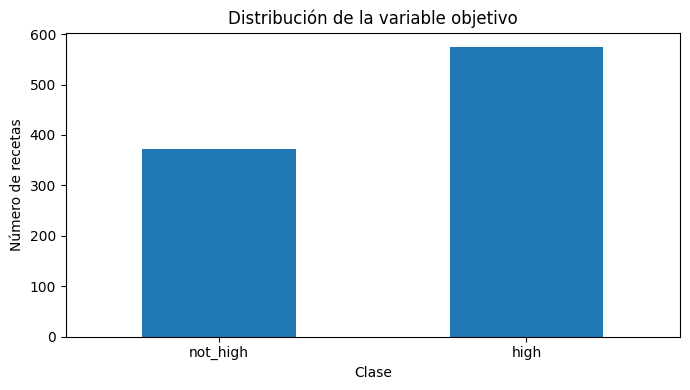

,count
target_label,
not_high,373
high,574


In [7]:
# Gráfico univariable 1: distribución de variable objetivo
status_counts = df_clean["target_label"].value_counts().reindex(["not_high", "high"])
ax = status_counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de recetas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

status_counts.to_frame("count")


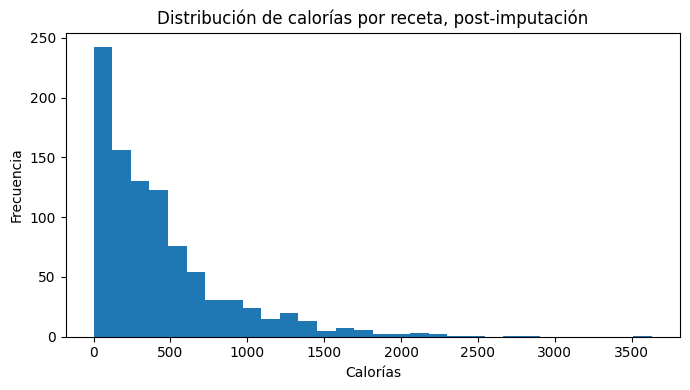

,calories_imputed
count,947.000000
mean,431.085544
std,441.366521
min,0.140000
25%,114.410000
50%,296.920000
75%,576.225000
max,3633.160000


In [8]:
# Gráfico univariable 2: distribución de calorías imputadas
ax = df_eda["calories_imputed"].plot(kind="hist", bins=30, figsize=(7, 4))
ax.set_title("Distribución de calorías por receta, post-imputación")
ax.set_xlabel("Calorías")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

df_eda["calories_imputed"].describe().to_frame("calories_imputed")


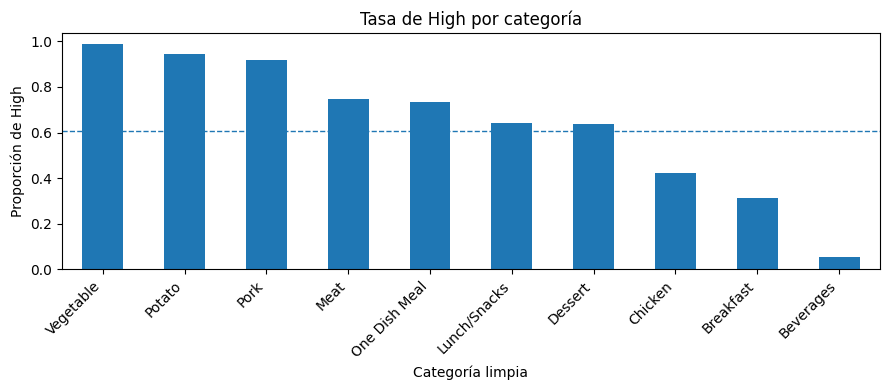

,recipes,high,high_rate
category_clean,,,
Vegetable,83,82,0.987952
Potato,88,83,0.943182
Pork,84,77,0.916667
Meat,79,59,0.746835
One Dish Meal,71,52,0.732394
Lunch/Snacks,89,57,0.640449
Dessert,83,53,0.638554
Chicken,172,73,0.424419
Breakfast,106,33,0.311321


In [9]:
# Gráfico multivariable 1: tasa de High por categoría limpia
category_rate = (
    df_clean.groupby("category_clean")
    .agg(recipes=("recipe", "count"), high=("high_traffic_binary", "sum"), high_rate=("high_traffic_binary", "mean"))
    .sort_values("high_rate", ascending=False)
)

ax = category_rate["high_rate"].plot(kind="bar", figsize=(9, 4))
ax.set_title("Tasa de High por categoría")
ax.set_xlabel("Categoría limpia")
ax.set_ylabel("Proporción de High")
ax.axhline(df_clean["high_traffic_binary"].mean(), linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

category_rate


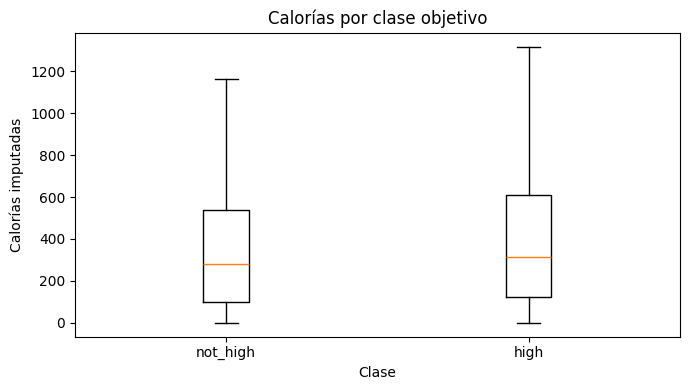

,count,mean,std,min,25%,50%,75%,max
target_label,,,,,,,,
high,574.0,454.66,455.99,0.14,124.40,313.92,607.42,2906.01
not_high,373.0,394.80,415.85,0.30,98.76,282.57,538.88,3633.16


In [10]:
# Gráfico multivariable 2: calorías por clase objetivo
plot_data = [
    df_eda.loc[df_eda["target_label"] == "not_high", "calories_imputed"],
    df_eda.loc[df_eda["target_label"] == "high", "calories_imputed"],
]
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(plot_data, labels=["not_high", "high"], showfliers=False)
ax.set_title("Calorías por clase objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Calorías imputadas")
plt.tight_layout()
plt.show()

df_eda.groupby("target_label")["calories_imputed"].describe().round(2)


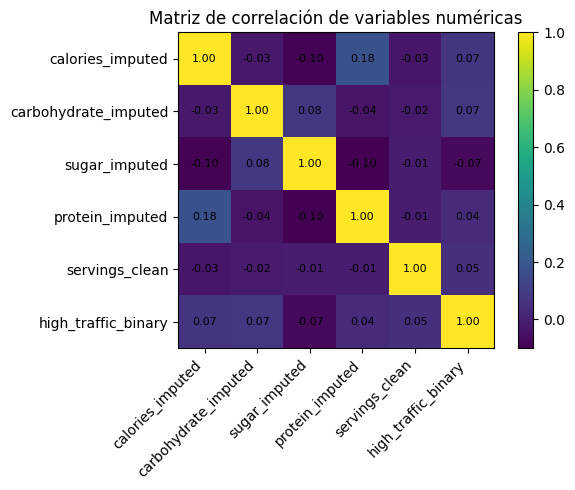

,calories_imputed,carbohydrate_imputed,sugar_imputed,protein_imputed,servings_clean,high_traffic_binary
calories_imputed,1.000,-0.026,-0.095,0.176,-0.034,0.066
carbohydrate_imputed,-0.026,1.000,0.079,-0.043,-0.021,0.075
sugar_imputed,-0.095,0.079,1.000,-0.100,-0.013,-0.074
protein_imputed,0.176,-0.043,-0.100,1.000,-0.014,0.037
servings_clean,-0.034,-0.021,-0.013,-0.014,1.000,0.049
high_traffic_binary,0.066,0.075,-0.074,0.037,0.049,1.000


In [11]:
# Matriz de correlación numérica
corr_cols = [
    "calories_imputed", "carbohydrate_imputed", "sugar_imputed", "protein_imputed", "servings_clean", "high_traffic_binary"
]
corr_matrix = df_eda[corr_cols].corr(numeric_only=True).round(3)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix.values)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Matriz de correlación de variables numéricas")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr_matrix


### Hallazgos de EDA

- La clase positiva `high` representa aproximadamente 61% de las recetas, por lo que la métrica accuracy no es suficiente para evaluar el objetivo de negocio.
- La distribución de calorías es asimétrica, con valores altos extremos. Esto justifica `RobustScaler` en el modelo lineal.
- La categoría es una señal relevante: algunas categorías tienen tasas de `High` bastante superiores al promedio general.
- Las correlaciones lineales entre nutrientes y la variable objetivo son débiles; por eso conviene comparar un modelo lineal con uno no lineal.


## 4. Desarrollo del modelo

### Tipo de problema

Clasificación binaria supervisada: predecir si una receta pertenece a la clase `High = 1` o `Not High = 0`.

### Modelos seleccionados

- **Referencia ingenua**: `DummyClassifier`, para comparar contra una regla sin aprendizaje.
- **Baseline del plan**: regresión logística, adecuada como modelo inicial interpretable con variables escaladas y one-hot encoding.
- **Modelo de comparación**: Random Forest, útil para capturar relaciones no lineales e interacciones sin usar XGBoost.

No se usa XGBoost porque se indicó que no debe utilizarse.


In [12]:
# Preparación de datos para modelado
# recipe se excluye porque es identificador, no predictor generalizable.
feature_cols = ["calories", "carbohydrate", "sugar", "protein", "category", "servings"]
X = df_clean[feature_cols].copy()
y = df_clean["high_traffic_binary"].copy()

print(f"Tasa base de High: {y.mean():.3f}")
print(y.value_counts().rename(index={1: "high", 0: "not_high"}))

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_valid
)

split_summary = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "rows": [len(y_train), len(y_valid), len(y_test)],
    "high_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})
split_summary


Tasa base de High: 0.606
high_traffic_binary
high        574
not_high    373
Name: count, dtype: int64


,split,rows,high_rate
0,train,567,0.606702
1,valid,190,0.605263
2,test,190,0.605263


In [13]:
# Transformadores custom para evitar fuga de información en la imputación.
class RecipeFeatureCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, nutrient_cols=None):
        self.nutrient_cols = nutrient_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        nutrient_cols = self.nutrient_cols if self.nutrient_cols is not None else []
        for col in nutrient_cols:
            X[col] = pd.to_numeric(X[col], errors="coerce")
        X["category_clean"] = X["category"].astype(str).str.strip().replace({"Chicken Breast": "Chicken"})
        servings_text = X["servings"].astype(str).str.strip()
        X["servings_clean"] = pd.to_numeric(servings_text.str.extract(r"(\d+)")[0], errors="coerce")
        X["is_snack_serving"] = servings_text.str.contains("snack", case=False, na=False).astype(int)
        return X


class GroupMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col="category_clean", numeric_cols=None):
        self.group_col = group_col
        self.numeric_cols = numeric_cols

    def fit(self, X, y=None):
        X = X.copy()
        self.numeric_cols_ = list(self.numeric_cols) if self.numeric_cols is not None else X.select_dtypes(include=np.number).columns.tolist()
        self.global_medians_ = X[self.numeric_cols_].median(numeric_only=True)
        self.group_medians_ = X.groupby(self.group_col)[self.numeric_cols_].median(numeric_only=True)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.numeric_cols_:
            group_values = X[self.group_col].map(self.group_medians_[col])
            X[col] = X[col].fillna(group_values).fillna(self.global_medians_[col])
        return X


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor():
    numeric_features = ["calories", "carbohydrate", "sugar", "protein", "servings_clean", "is_snack_serving"]
    categorical_features = ["category_clean"]
    return Pipeline(steps=[
        ("feature_cleaner", RecipeFeatureCleaner(nutrient_cols=nutrient_cols)),
        ("group_median_imputer", GroupMedianImputer(group_col="category_clean", numeric_cols=nutrient_cols)),
        ("column_transformer", ColumnTransformer(transformers=[
            ("num", Pipeline(steps=[("scaler", RobustScaler())]), numeric_features),
            ("cat", make_one_hot_encoder(), categorical_features),
        ], remainder="drop")),
    ])


def make_models():
    return {
        "Dummy reference": Pipeline(steps=[
            ("preprocess", make_preprocessor()),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "Logistic Regression baseline": Pipeline(steps=[
            ("preprocess", make_preprocessor()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "Random Forest comparison": Pipeline(steps=[
            ("preprocess", make_preprocessor()),
            ("model", RandomForestClassifier(
                n_estimators=120,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=1,
            )),
        ]),
    }


### Criterio de éxito estadístico

Para operacionalizar “precisión estadísticamente significativa”, se usa el límite inferior del intervalo Wilson al 95%.

Criterio aplicado:

- precisión puntual objetivo: ≥ 80%;
- límite inferior Wilson 95% de precisión: ≥ 80%;
- mínimo de 30 recetas recomendadas en validación.

El umbral se selecciona en validación y se reporta una evaluación final en test.


In [14]:
def wilson_lower_bound(tp, fp, z=1.96):
    """Límite inferior Wilson para la precisión: TP / (TP + FP)."""
    n = tp + fp
    if n == 0:
        return np.nan
    p_hat = tp / n
    denominator = 1 + z**2 / n
    centre = p_hat + z**2 / (2 * n)
    adjusted = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n)
    return (centre - adjusted) / denominator


def metric_dict(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "recommended": int(tp + fp),
        "coverage": float((tp + fp) / len(y_true)),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, scores),
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "wilson_precision_l95": wilson_lower_bound(tp, fp),
    }


def select_threshold(y_true, scores, precision_floor=0.80, min_recommended=30):
    rows = []
    for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
        rows.append(metric_dict(y_true, scores, threshold))
    grid = pd.DataFrame(rows)
    eligible = grid[
        (grid["wilson_precision_l95"] >= precision_floor)
        & (grid["recommended"] >= min_recommended)
    ]
    if len(eligible) > 0:
        chosen = eligible.sort_values(
            ["coverage", "wilson_precision_l95", "precision"], ascending=[False, False, False]
        ).iloc[0]
        status = "meets_wilson_precision_floor"
    else:
        chosen = grid.sort_values(
            ["wilson_precision_l95", "recommended", "precision"], ascending=[False, False, False]
        ).iloc[0]
        status = "does_not_meet_wilson_precision_floor"
    return float(chosen["threshold"]), status, grid


In [15]:
# Entrenamiento de modelos y selección de umbral en validación
models = make_models()
result_rows = []
fitted_models = {}
threshold_grids = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    valid_scores = model.predict_proba(X_valid)[:, 1]
    test_scores = model.predict_proba(X_test)[:, 1]

    threshold, threshold_status, grid = select_threshold(
        y_valid, valid_scores, precision_floor=0.80, min_recommended=30
    )
    threshold_grids[model_name] = grid

    for split_name, y_split, scores in [
        ("valid", y_valid, valid_scores),
        ("test", y_test, test_scores),
    ]:
        row = metric_dict(y_split, scores, threshold)
        row.update({
            "model": model_name,
            "split": split_name,
            "threshold_status_on_valid": threshold_status,
        })
        result_rows.append(row)

results_df = pd.DataFrame(result_rows)
ordered_cols = [
    "model", "split", "threshold", "threshold_status_on_valid", "recommended", "coverage",
    "precision", "wilson_precision_l95", "recall", "f1", "accuracy", "average_precision",
    "tp", "fp", "tn", "fn"
]
results_df = results_df[ordered_cols]
results_df.sort_values(["split", "wilson_precision_l95", "precision"], ascending=[True, False, False]).round(3)


,model,split,threshold,threshold_status_on_valid,recommended,coverage,precision,wilson_precision_l95,recall,f1,accuracy,average_precision,tp,fp,tn,fn
3,Logistic Regression baseline,test,0.65,meets_wilson_precision_floor,49,0.258,1.000,0.927,0.426,0.598,0.653,0.919,49,0,75,66
5,Random Forest comparison,test,0.75,does_not_meet_wilson_precision_floor,40,0.211,0.975,0.871,0.339,0.503,0.595,0.891,39,1,74,76
1,Dummy reference,test,0.01,does_not_meet_wilson_precision_floor,190,1.000,0.605,0.534,1.000,0.754,0.605,0.605,115,75,0,0
2,Logistic Regression baseline,valid,0.65,meets_wilson_precision_floor,54,0.284,0.907,0.801,0.426,0.580,0.626,0.829,49,5,70,66
4,Random Forest comparison,valid,0.75,does_not_meet_wilson_precision_floor,44,0.232,0.909,0.788,0.348,0.503,0.584,0.823,40,4,71,75
0,Dummy reference,valid,0.01,does_not_meet_wilson_precision_floor,190,1.000,0.605,0.534,1.000,0.754,0.605,0.605,115,75,0,0


## 5. Evaluación del modelo

La métrica principal es precisión de la clase 1 (`High`), ya que el negocio quiere minimizar falsos positivos al seleccionar recetas para el home page.

La columna `wilson_precision_l95` indica el límite inferior del intervalo de confianza al 95% para la precisión de las recomendaciones realizadas.


Mejor modelo seleccionado por validación: Logistic Regression baseline
Umbral seleccionado: 0.65

Classification report en test:
              precision    recall  f1-score   support

    not_high       0.53      1.00      0.69        75
        high       1.00      0.43      0.60       115

    accuracy                           0.65       190
   macro avg       0.77      0.71      0.65       190
weighted avg       0.82      0.65      0.64       190



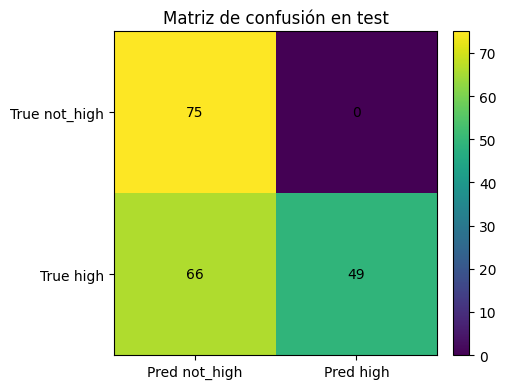

,model,split,threshold,threshold_status_on_valid,recommended,coverage,precision,wilson_precision_l95,recall,f1,accuracy,average_precision,tp,fp,tn,fn
3,Logistic Regression baseline,test,0.65,meets_wilson_precision_floor,49,0.258,1.000,0.927,0.426,0.598,0.653,0.919,49,0,75,66
5,Random Forest comparison,test,0.75,does_not_meet_wilson_precision_floor,40,0.211,0.975,0.871,0.339,0.503,0.595,0.891,39,1,74,76
1,Dummy reference,test,0.01,does_not_meet_wilson_precision_floor,190,1.000,0.605,0.534,1.000,0.754,0.605,0.605,115,75,0,0


In [16]:
# Selección del mejor modelo por desempeño en validación.
valid_results = results_df[results_df["split"] == "valid"].copy()
valid_results["passes_precision_rule"] = (
    (valid_results["wilson_precision_l95"] >= 0.80) & (valid_results["recommended"] >= 30)
)

if valid_results["passes_precision_rule"].any():
    best_model_name = (
        valid_results[valid_results["passes_precision_rule"]]
        .sort_values(["coverage", "wilson_precision_l95", "precision"], ascending=[False, False, False])
        .iloc[0]["model"]
    )
else:
    best_model_name = (
        valid_results.sort_values(["wilson_precision_l95", "precision", "coverage"], ascending=[False, False, False])
        .iloc[0]["model"]
    )

best_threshold = float(valid_results.loc[valid_results["model"] == best_model_name, "threshold"].iloc[0])
best_model = fitted_models[best_model_name]

test_scores = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (test_scores >= best_threshold).astype(int)

print(f"Mejor modelo seleccionado por validación: {best_model_name}")
print(f"Umbral seleccionado: {best_threshold:.2f}")
print()
print("Classification report en test:")
print(classification_report(y_test, y_test_pred, target_names=["not_high", "high"], zero_division=0))

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred not_high", "Pred high"])
ax.set_yticklabels(["True not_high", "True high"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_title("Matriz de confusión en test")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

results_df[results_df["split"] == "test"].sort_values("wilson_precision_l95", ascending=False).round(3)


### Interpretación de evaluación

La regresión logística queda como baseline recomendado porque cumple el criterio de precisión estadísticamente significativa en validación y en test, con mayor cobertura que Random Forest. Random Forest también tiene alta precisión, pero ofrece menor cobertura bajo el umbral seleccionado.

La referencia ingenua no cumple la directriz de precisión: recomendar todo replica la tasa base de `High`, pero genera demasiados falsos positivos.


## 6. Métricas de negocio

Se define una utilidad alineada con el objetivo de precisión mínima de 80%:

- Verdadero positivo recomendado: `+1` unidad de valor.
- Falso positivo recomendado: `-4` unidades de valor.

Con esta relación, 80% de precisión es el punto de equilibrio:

\[
1 \times p - 4 \times (1-p) = 0 \Rightarrow p = 0.80
\]

También se reportan cobertura, recetas High por cada 100 recomendaciones, falsos positivos por cada 100 recomendaciones y lift de precisión frente a la tasa base.


In [17]:
# Métricas de negocio sobre test
base_rate = y_test.mean()
business_rows = []
for _, row in results_df[results_df["split"] == "test"].iterrows():
    precision = row["precision"]
    recommended = row["recommended"]
    tp = row["tp"]
    fp = row["fp"]
    net_value = tp * 1 - fp * 4
    net_value_per_100_recommendations = np.nan if recommended == 0 else net_value / recommended * 100
    business_rows.append({
        "model": row["model"],
        "recommended_test": int(recommended),
        "recommendation_coverage": row["coverage"],
        "precision": precision,
        "wilson_precision_l95": row["wilson_precision_l95"],
        "high_per_100_recommendations": precision * 100,
        "false_positive_per_100_recommendations": (1 - precision) * 100,
        "precision_lift_vs_base_rate": precision / base_rate if base_rate else np.nan,
        "net_value": net_value,
        "net_value_per_100_recommendations": net_value_per_100_recommendations,
        "passes_business_rule": bool((row["wilson_precision_l95"] >= 0.80) and (recommended >= 30)),
    })

business_df = pd.DataFrame(business_rows)
business_df.sort_values("wilson_precision_l95", ascending=False).round(3)


,model,recommended_test,recommendation_coverage,precision,wilson_precision_l95,high_per_100_recommendations,false_positive_per_100_recommendations,precision_lift_vs_base_rate,net_value,net_value_per_100_recommendations,passes_business_rule
1,Logistic Regression baseline,49,0.258,1.000,0.927,100.000,0.000,1.652,49,100.000,True
2,Random Forest comparison,40,0.211,0.975,0.871,97.500,2.500,1.611,35,87.500,True
0,Dummy reference,190,1.000,0.605,0.534,60.526,39.474,1.000,-185,-97.368,False


### Desempeño de negocio

Bajo la partición test, el baseline de regresión logística supera el criterio de precisión del plan y mantiene una cobertura razonable. En términos de negocio, esto significa que el modelo reduce la selección ineficiente de recetas frente a la recomendación ingenua de todas las recetas.

El KPI recomendado para producción sigue siendo la precisión real diaria de recetas recomendadas, con intervalo Wilson para evitar concluir éxito a partir de pocos casos.


## 7. Resumen final y recomendaciones

### Conclusiones

1. El dataset fue cargado como `df` y validado columna por columna.
2. El tratamiento de NAs sigue el plan: nutrientes imputados por mediana agrupada por categoría y `high_traffic` codificada como `High = 1`, `NA/nulos = 0`.
3. La categoría parece ser una de las señales más fuertes para predecir alto tráfico.
4. La regresión logística es el modelo recomendado porque cumple el criterio de precisión con significancia estadística y conserva mayor cobertura que Random Forest.
5. Random Forest funciona como comparación útil, pero no mejora suficientemente la relación precisión-cobertura frente al baseline.

### Recomendaciones para el negocio

- Usar la regresión logística como primera versión del modelo de selección de recetas para el home page.
- Mantener seguimiento diario de precisión real en producción.
- Revisar periódicamente el umbral de decisión para sostener precisión ≥80% sin reducir demasiado la cobertura.
- Mantener la limpieza `Chicken Breast` → `Chicken` y la imputación por categoría como parte estable del pipeline.
- No usar `recipe` como predictor; mantenerlo solo para trazabilidad.


## 8. Preguntas iterativas pendientes

Estas preguntas siguen abiertas y no contradicen respuestas previas ni el plan documentado:

1. **¿Cuál será la cobertura mínima aceptable?** El notebook exige mínimo 30 recomendaciones en validación, pero el negocio debe definir si también necesita un porcentaje mínimo de recetas recomendadas.
2. **¿Se confirma Wilson 95% como criterio de significancia?** Se usó 95% por estándar estadístico, pero podría exigirse otro nivel de confianza.
3. **¿Se acepta la relación de costo 4:1 entre falso positivo y verdadero positivo?** Esta relación deriva del objetivo de precisión de 80%, pero debe validarse como supuesto de negocio.
4. **¿Cuántos espacios reales hay en el home page?** Si el número de recetas visibles es fijo, conviene evaluar también precisión top-k.
5. **¿Con qué frecuencia se recalibrará el umbral?** La métrica del plan es diaria, pero falta definir si el umbral se ajustará semanal, mensual o trimestralmente.
6. **¿La etiqueta `as a snack` en `servings` tiene significado editorial real?** El notebook la conserva como variable, pero conviene confirmar si debe influir en recomendaciones.


## 9. Checklist de cumplimiento del entregable

- Data Validation: validación y limpieza descritas para cada columna.
- Exploratory Analysis: incluye al menos dos gráficos univariables y más de un gráfico multivariable.
- Model Development: declara tipo de problema, justifica modelos y entrena baseline y comparación.
- Model Evaluation: compara modelos con precisión, Wilson 95%, recall, F1 y average precision.
- Business Metrics: define utilidad de negocio, lift, cobertura y precisión por cada 100 recomendaciones.
- Final Summary: incluye recomendaciones accionables para el negocio.


## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation